In [ ]:
import torch
import importlib
import numpy as np
from scipy.optimize import minimize
from modele import *
from visualisation import *
import pytorch_optim
importlib.reload(pytorch_optim)
from pytorch_optim import *
%load_ext autoreload
%autoreload 2


In [ ]:
N=5
nb_colonnes_default = 50
T = 300
L = 5
P0 = torch.tensor([[0, 0, 1], [0, 1, 0], [1, 0, 0]]) 
params = {
    "N": N,  # nombre de couches
    "L": L,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": 50,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": T,  # temps final pour 20 tours
    "CFL": 0.95,  # facteur CFL
    "u" : [0.1]*N,
    "I_s": 1500, #1500 initialement
    "epsilon": 4.6, #pour une luminosité de 1% au fond du bassin
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}

In [6]:
params["N"] = 5
params["u"] = [0.1]*5
masse_permut, _, _ = meilleure_matrice_de_permutation(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params)
res = solve_optimize(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params, matrix_to_vector(np.identity(params["N"])))#P, biomass_list = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params)
#print(biomass_list[-1])
masse_bisto = -res.fun
print(masse_permut, masse_bisto)
print(np.abs(masse_bisto - masse_permut)/masse_permut)

50.21409768742719 up
50.2141024462869 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.214102453723186 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.21410245934252 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.214102458519456 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.214102451995274 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.21409768742719 up
50.39658 -50.21409768742719
1.9963790785815807


In [5]:
res = solve_optimize_stochastic(X_ini_one_layer(N, nb_colonnes_default), T, params, matrix_to_vector(np.identity(5)))

50.21409768742719
50.2141024462869
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.214102453723186
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245934252
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.214102458519456
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.214102451995274
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.42773101589165
50.427732334999575
50.42773101589165
50.427732912333255
50.427732574685706
50.42773101589165
50.42773233456082
50.42773101589165
50.42773291278371
50.42773257505595
50.42773101589165
50.42773233705457
50.42773101589165
50.42773291450237
50.42773257646862
50.42773101589165
50.42773233668925
50.42773101589165
50.42773291425062
50.427732576261796
50.42773101589165
50.42773233379422
50.42773101589165
50.42773291225514
50.42773257462147
50.42773101589165
50.43889759810333
50.438898726475784
50.43889759810333
50.

In [4]:
print(vector_to_matrix(res.x))

NameError: name 'res' is not defined

Histogramme

In [ ]:
params["N"] = 4
params["u"] = [0.1]*4
biomasse_permutation, M, _ = meilleure_matrice_de_permutation(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params)
res_0 = solve_optimize(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params, matrix_to_vector(M))
R0 = vector_to_matrix(res_0.x, params["N"])
liste_biomasses_bisto = []
liste_distances = []
for k in range(20):
    res = solve_optimize(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params, matrix_to_vector(np.random.randn(params["N"], params["N"])))
    b = res.fun
    liste_biomasses_bisto.append(b)
    R = res.x
    R = vector_to_matrix(R, params["N"])
    liste_distances.append(np.linalg.norm(R - R0, 'fro'))
print(liste_distances)
print(liste_biomasses_bisto)

50.38397182359854
50.38397333001698
50.3839728051602
50.383973315399544
50.383972617210794
50.38397333042599
50.38397280518328
50.38397331587117
50.38397261714885
50.383973331045524
50.383972805498516
50.38397331618829
50.38397261759043
50.383973329983554
50.383972805218264
50.383973315680755
50.38397261708233
1922.3751177386398
1922.3751558694257
1922.3751401067934
1922.3750813776571
1922.3751519012123
1922.3751386435983
1922.3751371785097
1922.3750883281364
1922.375141278027
1922.375096701198
1922.3751189114712
1922.3751208248696
1922.3751084823878
1922.375163272934
1922.3751342668138
1922.3750852663961
1922.3751517046458
50.293955480697434
50.29395796468947
50.29395548069616
50.293955480735775
50.29395776248744
50.2939579681376
50.29395548069614
50.293955480735775
50.29395776507022
50.29395797064387
50.29395548069615
50.293955480735804
50.29395776689819
50.29395796530012
50.293955480696155
50.293955480735754
50.29395776306762
50.298707213410644
50.29870963238399
50.29870733887594
50

Text(0, 0.5, 'frequence')

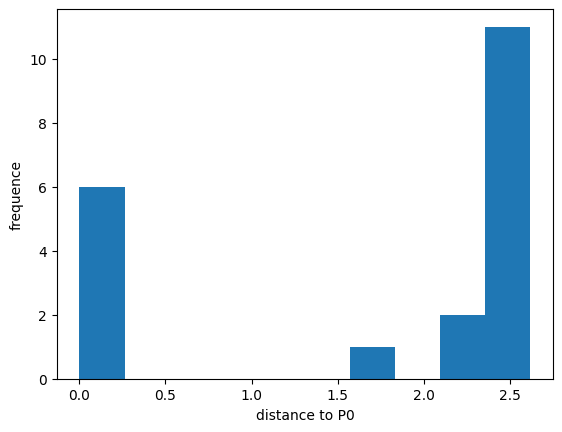

In [52]:
plt.hist(liste_distances, bins=10)
plt.xlabel("distance to P0") #P0 trouvé en lançant solve depuis meilleure matrice permut
plt.ylabel("frequence")

In [2]:
plt.plot(liste_distances, [-l for l in liste_biomasses_bisto], '.')

NameError: name 'liste_distances' is not defined

distance à P_permutation

In [8]:
def matrice_bistochastique_distance_d(M, d, H):
    epsilon = d/np.linalg.norm(H - M, 'fro')
    B = (1-epsilon)*M + epsilon*H
    return B

In [ ]:
#liste de toutes les matrices de permutation
matrices_de_permutation = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params)
print(matrices_de_permutation)

[array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]]), array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]]), array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]]), array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]]), array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])]


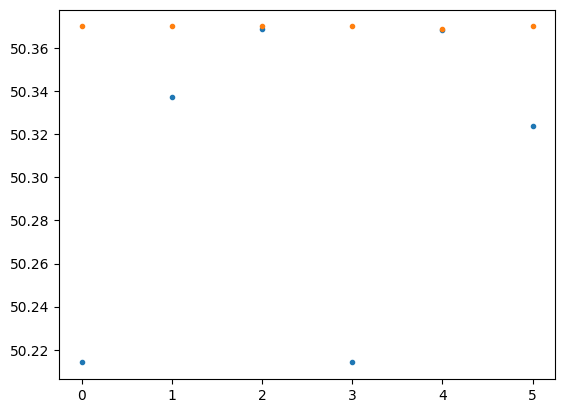

In [ ]:
plt.plot([k for k in range(6)], list_1, '.')
plt.plot([k for k in range(6)], [-l for l in list_2], '.')
plt.xlabel("permutation matrix")
plt.ylabel("final biomass (Kg)")

In [5]:
_, M, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params)
res = solve_optimize(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params, matrix_to_vector(np.identity(params["N"])))
R = vector_to_matrix(res.x, params["N"])

H = M + (R - M)*2


50.21409768742719
50.2141024462869
50.21409768742719
50.21409768742719
50.21410245802246
50.21409768742719
50.21409768742719
50.21410245675546
50.21409768742719
50.21409768742719
50.328340697103
50.32834337802095
50.32834181551414
50.32834166458702
50.32834338174369
50.32834181676027
50.32834166565462
50.32834338130085
50.328341816617275
50.328341665532264
50.33933587299305
50.339338335645536
50.33933710025714
50.339336951035975
50.339338338548345
50.33933710149614
50.3393369521131
50.33933833815874
50.33933710134148
50.339336951979014
50.352426204262
50.35242840231827
50.352427559725456
50.35242742033191
50.35242840425687
50.35242756084016
50.352427421322375
50.35242840393585
50.35242756067332
50.35242742117525
50.359331079223736
50.35933313647752
50.35933249825581
50.35933237354416
50.359333137930726
50.359332499223626
50.35933237442059
50.359333137655376
50.35933249905534
50.35933237426991
50.36501336680254
50.36501530681582
50.36501483423079
50.36501473089026
50.365015307889436
50.

In [6]:
print(M)
print(H)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
[[1.72344521e-01 1.94315098e-14 8.27655479e-01]
 [8.27655479e-01 1.72344521e-01 6.29078269e-17]
 [3.83774090e-16 8.27655479e-01 1.72344521e-01]]


In [9]:
list = []
for k in range(11): #nombre de matrices proches de la matrice de permutation
    d = np.linalg.norm(H - M, 'fro')*k/10
    B = matrice_bistochastique_distance_d(M, d, H)
    print(B)
    b = fonction_objectif(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, B, params)
    list.append(b)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
[[1.72344521e-02 1.94315098e-15 9.82765548e-01]
 [9.82765548e-01 1.72344521e-02 6.29078269e-18]
 [3.83774090e-17 9.82765548e-01 1.72344521e-02]]
[[3.44689043e-02 3.88630197e-15 9.65531096e-01]
 [9.65531096e-01 3.44689043e-02 1.25815654e-17]
 [7.67548180e-17 9.65531096e-01 3.44689043e-02]]
[[5.17033564e-02 5.82945295e-15 9.48296644e-01]
 [9.48296644e-01 5.17033564e-02 1.88723481e-17]
 [1.15132227e-16 9.48296644e-01 5.17033564e-02]]
[[6.89378086e-02 7.77260394e-15 9.31062191e-01]
 [9.31062191e-01 6.89378086e-02 2.51631308e-17]
 [1.53509636e-16 9.31062191e-01 6.89378086e-02]]
[[8.61722607e-02 9.71575492e-15 9.13827739e-01]
 [9.13827739e-01 8.61722607e-02 3.14539134e-17]
 [1.91887045e-16 9.13827739e-01 8.61722607e-02]]
[[1.03406713e-01 1.16589059e-14 8.96593287e-01]
 [8.96593287e-01 1.03406713e-01 3.77446961e-17]
 [2.30264454e-16 8.96593287e-01 1.03406713e-01]]
[[1.20641165e-01 1.36020569e-14 8.79358835e-01]
 [8.79358835e-01 1.20641165e-01 4.40354788e-1

Text(0, 0.5, 'objective function (Kg)')

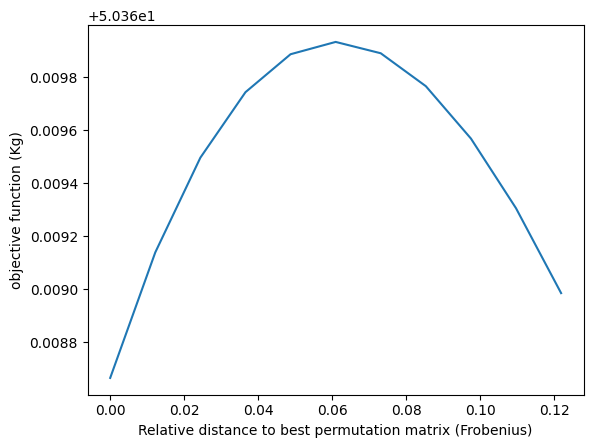

In [11]:
absc = [np.linalg.norm(R - M, 'fro')*k/(10*np.linalg.norm(M)) for k in range(11)]
plt.plot(absc, list)
plt.xlabel("Relative distance to best permutation matrix (Frobenius)")
plt.ylabel("objective function (Kg)")

Taux de variation

In [ ]:
for n in range(3, 6):
    M = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params)
    

Test : flashing effect

In [ ]:
params["N"] = 5
params["u"] = [0.1]*5
matrices = {}
biomasses = {}
for l in [1, 5, 10, 25, 50] :
    params["nb_colonnes_default"] = l*10
    params["L"] = l
    P, biomass_list = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    matrices[f'P{l}'] = P
    biomasses[f'B{l}'] = biomass_list
    print(P, biomass_list[-1])

obj: tensor(50.3585, grad_fn=<AddBackward0>) pen: tensor(0.0812, grad_fn=<SumBackward0>)
obj: tensor(50.3524, grad_fn=<AddBackward0>) pen: tensor(0.0356, grad_fn=<SumBackward0>)
obj: tensor(50.3463, grad_fn=<AddBackward0>) pen: tensor(0.0504, grad_fn=<SumBackward0>)
obj: tensor(50.3453, grad_fn=<AddBackward0>) pen: tensor(0.0359, grad_fn=<SumBackward0>)
obj: tensor(50.3474, grad_fn=<AddBackward0>) pen: tensor(0.0336, grad_fn=<SumBackward0>)
obj: tensor(50.3509, grad_fn=<AddBackward0>) pen: tensor(0.0218, grad_fn=<SumBackward0>)
obj: tensor(50.3540, grad_fn=<AddBackward0>) pen: tensor(0.0096, grad_fn=<SumBackward0>)
obj: tensor(50.3556, grad_fn=<AddBackward0>) pen: tensor(0.0120, grad_fn=<SumBackward0>)
obj: tensor(50.3554, grad_fn=<AddBackward0>) pen: tensor(0.0200, grad_fn=<SumBackward0>)
obj: tensor(50.3539, grad_fn=<AddBackward0>) pen: tensor(0.0212, grad_fn=<SumBackward0>)
obj: tensor(50.3520, grad_fn=<AddBackward0>) pen: tensor(0.0157, grad_fn=<SumBackward0>)
obj: tensor(50.3503, 

In [19]:
params["N"] = 3
params["u"] = [0.1]*3
matrices = {}
biomasses = {}
for l in [0.3, 1, 5, 10, 15, 20, 25, 50, 75, 100, 150] :
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    print(meilleure_masse, meilleure_matrice)

50.32933169061667 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.32968454422438 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.32871725242194 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.328364351760364 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.359217978920285 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.35983356257357 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.34525989963021 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.26297024241707 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.23288691970242 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.21784525834525 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
50.20280359698786 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


Text(0, 0.5, 'final biomass')

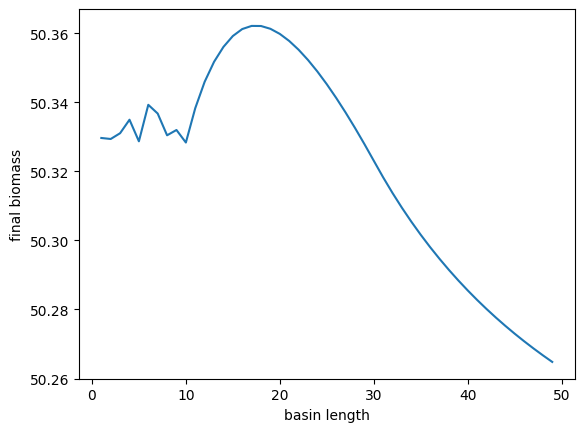

In [7]:
params["N"] = 3
params["u"] = [0.1]*3
masses = []
for l in range(1, 50):
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    masses.append(meilleure_masse)
    
plt.plot([k for k in range(1, 50)], masses)
plt.xlabel("basin length")
plt.ylabel("final biomass")

et est-ce qu'on observe aussi le falshing effect avec une vitesse évolutive ?

ValueError: x and y must have same first dimension, but have shapes (50,) and (49,)

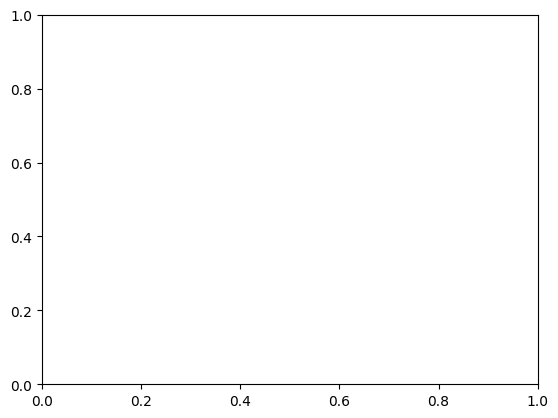

In [11]:
params["N"] = 3
params["u"] = [0.1]*3
masses = []
for l in range(1, 50):
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse = fonction_objectif(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, P0, params)
    masses.append(meilleure_masse)
    
plt.plot([k for k in range(50)], masses)

In [18]:
params["N"] = 4
params["u"] = [0.1]*4
matrices = {}
biomasses = {}
for l in [1, 2, 5, 10, 15, 25, 50, 100] :
    params["nb_colonnes_default"] = int(l*10)
    params["L"] = l
    meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 50/(l*10)), T, params)
    print(meilleure_masse, meilleure_matrice)

50.36270884925297 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.362055017802554 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.36103093516114 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.37371633553097 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.39057609279154 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.35809548480737 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.26899199693378 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]
50.22085613560361 [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


Trouver à présent le gain de biomasse pour une matrice bistochastique en partant d'une matrice de permutation.

In [59]:
params["N"] = 4
params["u"] = [0.1]*4
params["nb_colonnes_default"] = 50
params["L"] = 5
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 1), T, params)
print(meilleure_masse, meilleure_matrice)

50.36103093516114 [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


In [67]:
M = [[float(m) for m in l] for l in meilleure_matrice]
print(M)
M = inverse_softmax(M)
print(M)
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params, 50, 1000, 0.2, True, torch.tensor(M))

[[0.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0]]
[[-5.0, -5.0, 0.0, -5.0], [-5.0, 0.0, -5.0, -5.0], [-5.0, -5.0, -5.0, 0.0], [0.0, -5.0, -5.0, -5.0]]
tensor([[0.0066, 0.0066, 0.9802, 0.0066],
        [0.0066, 0.9802, 0.0066, 0.0066],
        [0.0066, 0.0066, 0.0066, 0.9802],
        [0.9802, 0.0066, 0.0066, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3602, grad_fn=<AddBackward0>) pen: tensor(1.0658e-14, grad_fn=<SumBackward0>)
tensor([[0.0045, 0.0098, 0.9739, 0.0044],
        [0.0045, 0.9707, 0.0066, 0.0044],
        [0.0045, 0.0098, 0.0098, 0.9845],
        [0.9866, 0.0098, 0.0098, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3612, grad_fn=<AddBackward0>) pen: tensor(0.0005, grad_fn=<SumBackward0>)
tensor([[0.0060, 0.0073, 0.9788, 0.0060],
        [0.0060, 0.9781, 0.0066, 0.0060],
        [0.0060, 0.0073, 0.0073, 0.9814],
        [0.9821, 0.0073, 0.0073, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3605, grad_fn=<AddBack

In [68]:
print(P_bisto)

tensor([[0.0018, 0.0020, 0.9945, 0.0014],
        [0.0016, 0.9944, 0.0023, 0.0013],
        [0.0024, 0.0018, 0.0015, 0.9947],
        [0.9942, 0.0018, 0.0016, 0.0027]], grad_fn=<SoftmaxBackward0>)


In [69]:
params["N"] = 3
params["u"] = [0.1]*3
params["nb_colonnes_default"] = 50
params["L"] = 5
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"], 0, 1), T, params)
print(meilleure_masse, meilleure_matrice)

50.32871725242194 [[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [70]:
M = [[float(m) for m in l] for l in meilleure_matrice]
print(M)
M = inverse_softmax(M)
print(M)
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(params["N"], params["nb_colonnes_default"]), T, params, 50, 1000, 0.2, True, torch.tensor(M))

[[0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [1.0, 0.0, 0.0]]
[[-5.0, 0.0, -5.0], [-5.0, -5.0, 0.0], [0.0, -5.0, -5.0]]
tensor([[0.0066, 0.9867, 0.0066],
        [0.0066, 0.0066, 0.9867],
        [0.9867, 0.0066, 0.0066]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3294, grad_fn=<AddBackward0>) pen: tensor(0., grad_fn=<SumBackward0>)
tensor([[0.0045, 0.9803, 0.0098],
        [0.0045, 0.0099, 0.9803],
        [0.9910, 0.0099, 0.0099]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3300, grad_fn=<AddBackward0>) pen: tensor(0.0002, grad_fn=<SumBackward0>)
tensor([[0.0060, 0.9827, 0.0099],
        [0.0060, 0.0099, 0.9828],
        [0.9880, 0.0073, 0.0073]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3296, grad_fn=<AddBackward0>) pen: tensor(1.0647e-05, grad_fn=<SumBackward0>)
tensor([[0.0081, 0.9851, 0.0102],
        [0.0081, 0.0093, 0.9842],
        [0.9839, 0.0056, 0.0056]], grad_fn=<SoftmaxBackward0>)
obj: tensor(50.3292, grad_fn=<AddBackward0>) pen: tensor(3.8205e-05, grad_fn=<SumBackward0>)
tensor

In [71]:
print(P_bisto)

tensor([[0.0016, 0.9935, 0.0047],
        [0.0016, 0.0048, 0.9935],
        [0.9968, 0.0017, 0.0017]], grad_fn=<SoftmaxBackward0>)


Et maintenant avec d'autres configurations initiales. D'abord, uniforme.

In [73]:
params["N"] = 3
params["u"] = [0.1]*3
params["nb_colonnes_default"] = 50
params["L"] = 5
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_uniform(params["N"], params["nb_colonnes_default"], 1), T, params)
print(meilleure_masse, meilleure_matrice)

150.98712016540446 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [78]:
M = [[float(m) for m in l] for l in meilleure_matrice]
print(M)
M = inverse_softmax(M)
print(M)
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_uniform_torch(params["N"], params["nb_colonnes_default"]), T, params, 50, 1000, 0.2, True, torch.tensor(M))

[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]
[[0.0, -10.0, -10.0], [-10.0, 0.0, -10.0], [-10.0, -10.0, 0.0]]
tensor([[9.9991e-01, 4.5396e-05, 4.5396e-05],
        [4.5396e-05, 9.9991e-01, 4.5396e-05],
        [4.5396e-05, 4.5396e-05, 9.9991e-01]], grad_fn=<SoftmaxBackward0>)
obj: tensor(150.9874, grad_fn=<AddBackward0>) pen: tensor(3.5527e-15, grad_fn=<SumBackward0>)
tensor([[9.9986e-01, 3.0435e-05, 3.0433e-05],
        [6.7709e-05, 9.9992e-01, 3.0434e-05],
        [6.7712e-05, 4.5395e-05, 9.9994e-01]], grad_fn=<SoftmaxBackward0>)
obj: tensor(150.9876, grad_fn=<AddBackward0>) pen: tensor(8.7743e-09, grad_fn=<SumBackward0>)
tensor([[9.9980e-01, 2.5664e-05, 2.0807e-05],
        [9.9297e-05, 9.9992e-01, 2.0716e-05],
        [9.9381e-05, 5.5960e-05, 9.9996e-01]], grad_fn=<SoftmaxBackward0>)
obj: tensor(150.9878, grad_fn=<AddBackward0>) pen: tensor(3.7599e-08, grad_fn=<SumBackward0>)
tensor([[9.9971e-01, 2.4487e-05, 1.5184e-05],
        [1.4514e-04, 9.9990e-01, 1.4964e-05],
        [

Avec Newton :

In [8]:
print(params)

{'N': 3, 'L': 5, 'H': 1, 'nb_colonnes_default': 50, 'D': 1e-05, 'T': 300, 'CFL': 0.95, 'u': [0.01, 0.01, 0.01], 'I_s': 1500, 'epsilon': 4.6, 'k_d': 0.000299, 'k_r': 0.00048, 'k_h': 0.000364, 'tau': 6.849, 'sigma_H': 0.0029, 'theta': 1.0556e-06, 'I_star': np.float64(166.94501039780602), 'mu_max': np.float64(3.315108749636504e-05)}


In [ ]:
N_lignes = params["N"]
Q = torch.nn.Parameter(torch.randn(N_lignes, N_lignes))
def J(Q):
    P = torch.softmax(Q, dim=0)
    return(fonction_objectif_torch(X_ini_one_layer_torch(N_lignes, nb_colonnes_default), T, P, params))

Q_sol, masse_tot = Newton(J, Q, N_lignes**2)
print(torch.softmax(Q_sol, dim=0))
print(f'masse tot : {masse_tot}')

In [4]:
params["N"] = 10
params["u"] = [0.01]*10
N_lignes = 10
Q = torch.nn.Parameter(torch.randn(N_lignes, N_lignes))
def J(Q):
    P = torch.softmax(Q, dim=0)
    return(fonction_objectif_torch(X_ini_one_layer_torch(N_lignes, nb_colonnes_default), T, P, params))

Q_sol = Newton(J, Q, N_lignes**2)
print(torch.softmax(Q_sol, dim=0))

tensor([[1.3290e-14, 2.7162e-02, 0.0000e+00, 1.0938e-01, 2.4756e-01, 1.6755e-01,
         3.6056e-02, 1.6333e-01, 7.8205e-02, 1.5063e-02],
        [2.3543e-14, 7.1905e-02, 0.0000e+00, 6.4791e-03, 5.5823e-02, 1.1783e-01,
         9.0548e-02, 1.4811e-01, 4.8556e-02, 2.7833e-01],
        [1.0000e+00, 1.7997e-02, 1.0000e+00, 4.5417e-02, 7.9803e-02, 7.1097e-02,
         8.4329e-02, 9.3214e-03, 1.8424e-01, 4.3045e-02],
        [1.3179e-14, 1.3997e-01, 0.0000e+00, 1.4435e-01, 3.8766e-02, 2.3223e-02,
         2.8493e-02, 4.0821e-01, 5.8166e-02, 1.1596e-01],
        [3.5437e-14, 4.2584e-03, 0.0000e+00, 4.0058e-02, 6.6528e-02, 1.5439e-01,
         5.8696e-02, 1.6503e-02, 5.0319e-02, 1.5443e-01],
        [1.7814e-14, 1.8955e-01, 0.0000e+00, 2.5302e-02, 1.3777e-01, 2.3559e-01,
         1.1356e-02, 7.7366e-02, 3.6857e-01, 4.9532e-02],
        [2.5497e-14, 2.0290e-02, 0.0000e+00, 7.5081e-02, 1.5246e-01, 1.5904e-01,
         1.0986e-01, 3.2093e-02, 3.8182e-02, 8.3069e-02],
        [1.2876e-13, 1.0745